# Data Preparation Coursework - Heart Disease Dataset


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 2. Data Loading and Exploration

In [2]:
# Load the dataset
df = pd.read_csv('HeartDisease2026.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (922, 16)

First 5 rows:
   id  age   sex    dataset              cp  trestbps   chol    fbs         restecg  thalch  exang  oldpeak        slope   ca               thal  num
0   0   63  Male  Cleveland  typical angina     145.0  233.0   True  lv hypertrophy   150.0  False      2.3  downsloping  0.0       fixed defect    0
1   1   67  Male  Cleveland    asymptomatic     160.0  286.0  False  lv hypertrophy   108.0   True      1.5         flat  3.0             normal    2
2   2   67  Male  Cleveland    asymptomatic     160.0  286.0  False  lv hypertrophy   108.0   True      1.5         flat  3.0             normal    2
3   3   67  Male  Cleveland    asymptomatic     120.0  229.0  False  lv hypertrophy   129.0   True      2.6         flat  2.0  reversable defect    1
4   4   37  Male  Cleveland     non-anginal     130.0  250.0  False          normal   187.0  False      3.5  downsloping  0.0             normal    0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIn

In [3]:
# Statistical summary
print("Statistical Summary of Numerical Features:")
print(df.describe())

print("\nStatistical Summary of Categorical Features:")
print(df.describe(include=['object']))

Statistical Summary of Numerical Features:
               id         age     trestbps         chol      thalch     oldpeak          ca         num
count  922.000000  922.000000   862.000000   892.000000  866.000000  859.000000  310.000000  922.000000
mean   460.500000   53.331887   133.208817   200.021300  137.511547    0.879511    0.683871    0.997831
std    266.302773   10.287846    39.222443   116.659406   25.930730    1.090796    0.943414    1.148097
min      0.000000  -55.000000     0.000000     0.000000   60.000000   -2.600000    0.000000    0.000000
25%    230.250000   47.000000   120.000000   175.000000  120.000000    0.000000    0.000000    0.000000
50%    460.500000   54.000000   130.000000   223.000000  140.000000    0.500000    0.000000    1.000000
75%    690.750000   60.000000   140.000000   268.000000  157.000000    1.500000    1.000000    2.000000
max    921.000000   77.000000  1130.000000  1283.000000  202.000000    6.200000    3.000000    5.000000

Statistical Summary 

In [4]:
# Check unique values for each column
print("Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique values per column:
id: 922 unique values
age: 52 unique values
sex: 2 unique values
dataset: 4 unique values
cp: 4 unique values
trestbps: 62 unique values
chol: 219 unique values
fbs: 2 unique values
restecg: 3 unique values
thalch: 119 unique values
exang: 2 unique values
oldpeak: 53 unique values
slope: 3 unique values
ca: 4 unique values
thal: 3 unique values
num: 6 unique values


## 3. Data Cleaning

### 3.1 Missing Values Analysis

In [5]:
# Check for missing values
print("Missing Values Count:")
missing_counts = df.isnull().sum()
print(missing_counts)

print("\nMissing Values Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_data = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Percentage': missing_percentage.values
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_data)

Missing Values Count:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     60
chol         30
fbs          90
restecg       2
thalch       56
exang        56
oldpeak      63
slope       310
ca          612
thal        487
num           0
dtype: int64

Missing Values Percentage:
      Column  Missing_Count  Percentage
13        ca            612   66.377440
14      thal            487   52.819957
12     slope            310   33.622560
7        fbs             90    9.761388
11   oldpeak             63    6.832972
5   trestbps             60    6.507592
9     thalch             56    6.073753
10     exang             56    6.073753
6       chol             30    3.253796
8    restecg              2    0.216920


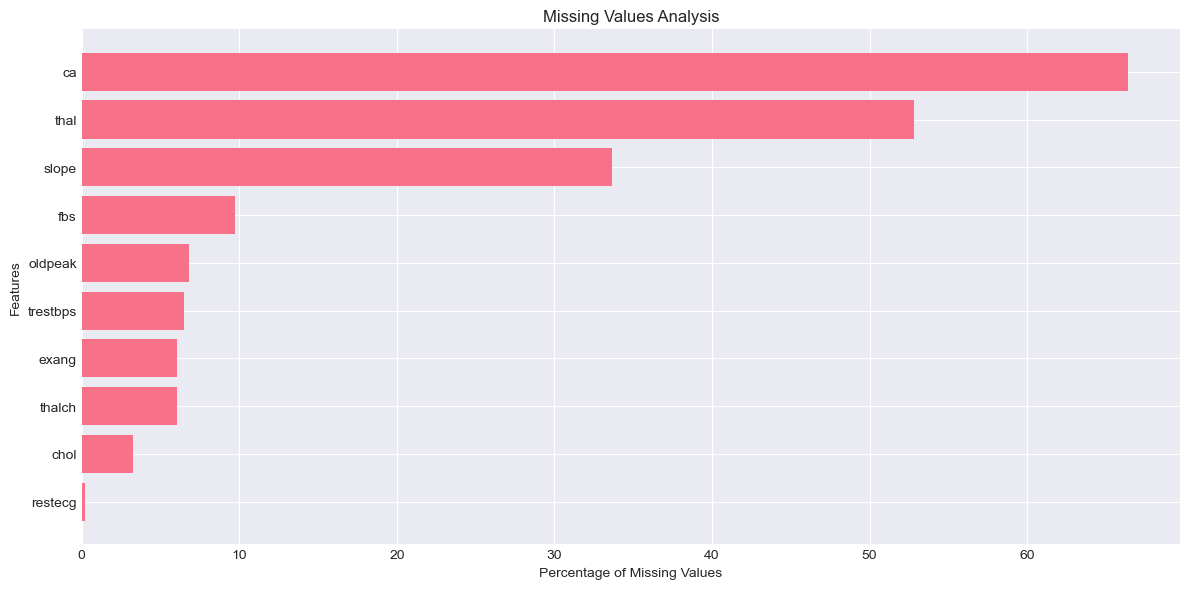


Total missing values: 1766
Percentage of dataset with any missing values: 67.46%


In [6]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_data_sorted = missing_data.sort_values('Percentage', ascending=True)
plt.barh(missing_data_sorted['Column'], missing_data_sorted['Percentage'])
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Features')
plt.title('Missing Values Analysis')
plt.tight_layout()
plt.show()

print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of dataset with any missing values: {(df.isnull().any(axis=1).sum() / len(df)) * 100:.2f}%")

### 3.2 Handling Missing Values


In [7]:
# Create a copy for imputation comparison
df_original = df.copy()

# Identify columns with high missing percentages
high_missing = missing_data[missing_data['Percentage'] > 60]['Column'].tolist()
print(f"Features with >60% missing: {high_missing}")

# Strategy 1: Drop rows with missing values (aggressive approach)
df_dropna = df.copy()
df_dropna_clean = df_dropna.dropna()
print(f"\nOriginal dataset: {len(df)} rows")
print(f"After dropping all NaN: {len(df_dropna_clean)} rows ({(len(df_dropna_clean)/len(df))*100:.2f}% retained)")

Features with >60% missing: ['ca']

Original dataset: 922 rows
After dropping all NaN: 300 rows (32.54% retained)


In [8]:
# Strategy 2: Simple Imputation
df_simple_impute = df.copy()

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Remove target and id columns from imputation
if 'num' in numerical_cols:
    numerical_cols.remove('num')
if 'id' in numerical_cols:
    numerical_cols.remove('id')

print(f"Numerical columns for imputation: {numerical_cols}")
print(f"Categorical columns for imputation: {categorical_cols}")

# Simple imputation for numerical columns (mean)
num_imputer = SimpleImputer(strategy='mean')
df_simple_impute[numerical_cols] = num_imputer.fit_transform(df_simple_impute[numerical_cols])

# Simple imputation for categorical columns (most frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
df_simple_impute[categorical_cols] = cat_imputer.fit_transform(df_simple_impute[categorical_cols])

print("\nMissing values after simple imputation:")
print(df_simple_impute.isnull().sum().sum())

Numerical columns for imputation: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns for imputation: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

Missing values after simple imputation:
0


In [9]:
# Strategy 3: Iterative Imputation (Advanced)
df_iterative = df.copy()

# First, encode categorical variables for iterative imputation
df_iterative_encoded = df_iterative.copy()
label_encoders = {}

for col in categorical_cols:
    le = OrdinalEncoder()
    # Handle NaN by adding it as a category
    mask = df_iterative_encoded[col].notna()
    if mask.sum() > 0:
        df_iterative_encoded.loc[mask, col] = le.fit_transform(df_iterative_encoded.loc[mask, [col]])
        label_encoders[col] = le

# Prepare features for iterative imputation (excluding id and target)
features_for_imputation = [col for col in df_iterative_encoded.columns if col not in ['id', 'num']]

# Apply iterative imputation
iter_imputer = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=42)
df_iterative_encoded[features_for_imputation] = iter_imputer.fit_transform(df_iterative_encoded[features_for_imputation])

print("\nMissing values after iterative imputation:")
print(df_iterative_encoded.isnull().sum().sum())

# Use simple imputation for the main workflow (more interpretable)
df_clean = df_simple_impute.copy()
print("\nUsing simple imputation for further analysis.")


Missing values after iterative imputation:
0

Using simple imputation for further analysis.


### 3.3 Duplicate Detection and Removal

In [10]:
# Check for duplicates
print("Duplicate Detection:")
print(f"Total duplicates: {df_clean.duplicated().sum()}")

# Check for duplicates excluding 'id' column
duplicates_without_id = df_clean.drop('id', axis=1).duplicated()
print(f"Duplicates (excluding ID): {duplicates_without_id.sum()}")

if duplicates_without_id.sum() > 0:
    print("\nDuplicated rows:")
    print(df_clean[duplicates_without_id])
    
    # Remove duplicates
    df_clean_dedup = df_clean.drop_duplicates(subset=df_clean.columns.difference(['id']), keep='first')
    print(f"\nRows after removing duplicates: {len(df_clean_dedup)}")
    df_clean = df_clean_dedup
else:
    print("\nNo duplicates found.")

Duplicate Detection:
Total duplicates: 0
Duplicates (excluding ID): 4

Duplicated rows:
      id   age     sex        dataset               cp    trestbps      chol    fbs           restecg      thalch  exang   oldpeak slope        ca    thal  num
2      2  67.0    Male      Cleveland     asymptomatic  160.000000  286.0000  False    lv hypertrophy  108.000000   True  1.500000  flat  3.000000  normal    2
406  406  49.0  Female        Hungary  atypical angina  110.000000  200.0213  False            normal  160.000000  False  0.000000  flat  0.683871  normal    0
908  908  58.0    Male  VA Long Beach      non-anginal  150.000000  219.0000  False  st-t abnormality  118.000000   True  0.000000  flat  0.683871  normal    2
918  918  62.0    Male  VA Long Beach   typical angina  133.208817  139.0000  False  st-t abnormality  137.511547  False  0.879511  flat  0.683871  normal    0

Rows after removing duplicates: 918


### 3.4 Outlier Detection

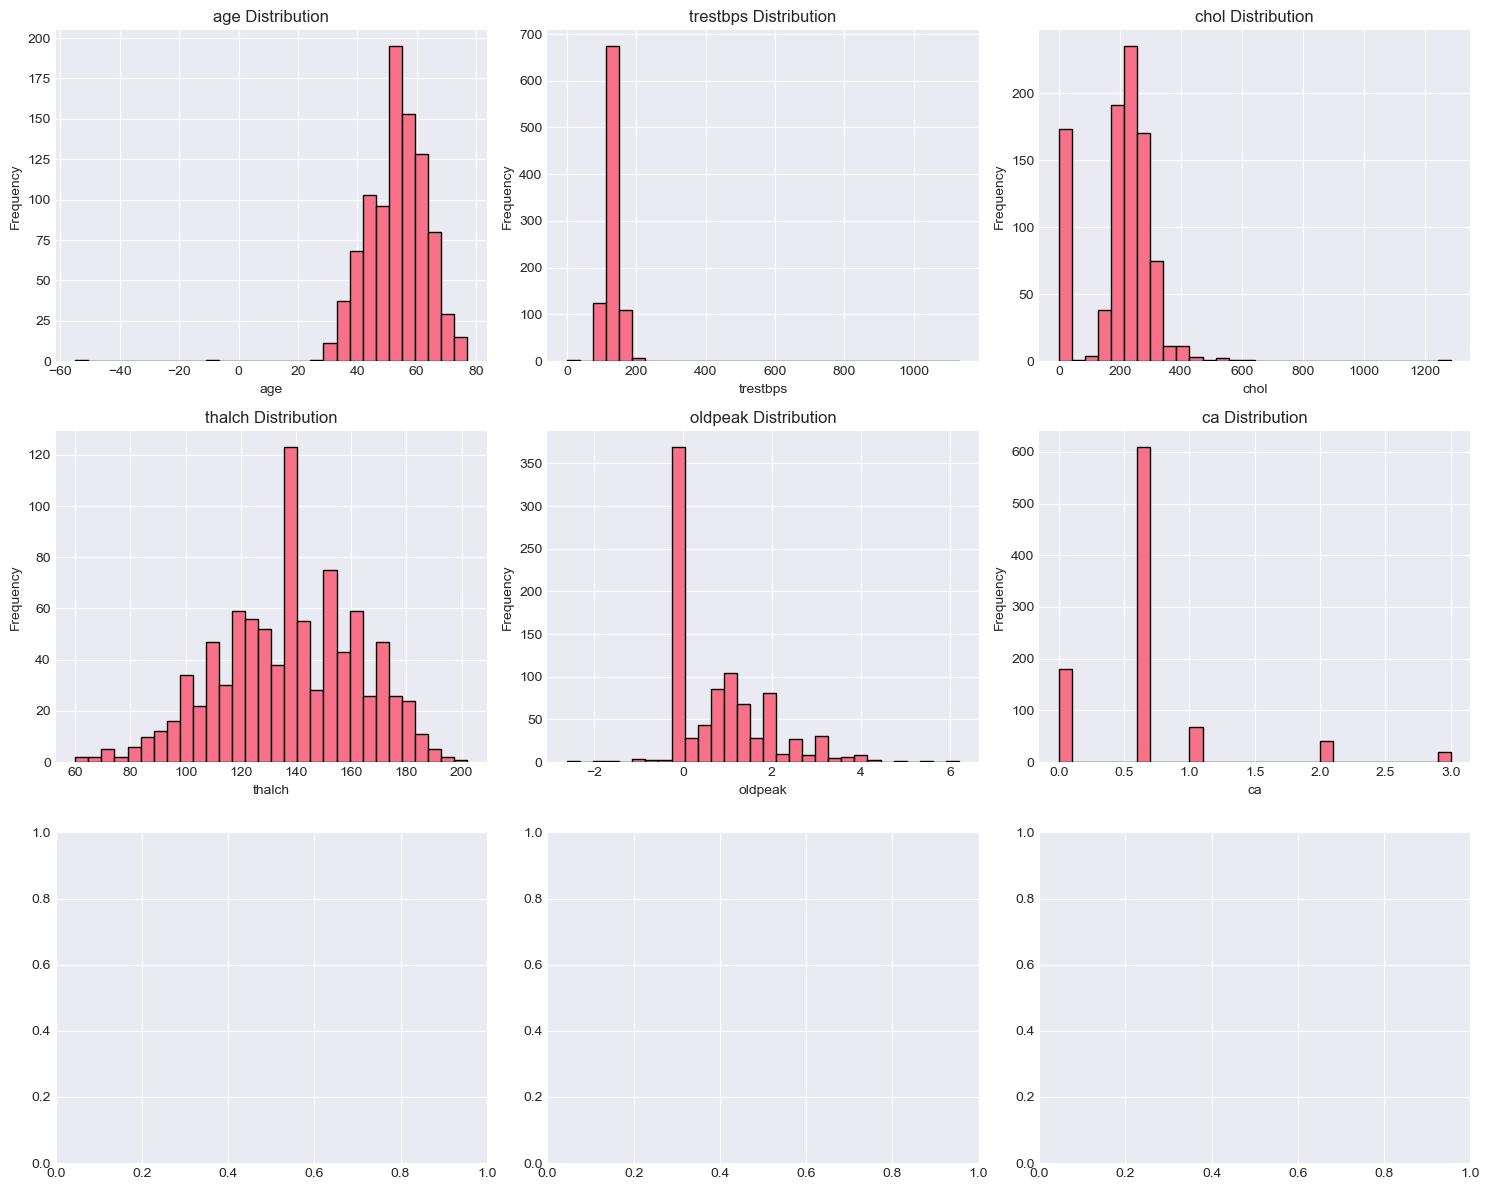

In [11]:
# Visualize distributions to identify outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < 9:
        axes[idx].hist(df_clean[col].dropna(), bins=30, edgecolor='black')
        axes[idx].set_title(f'{col} Distribution')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

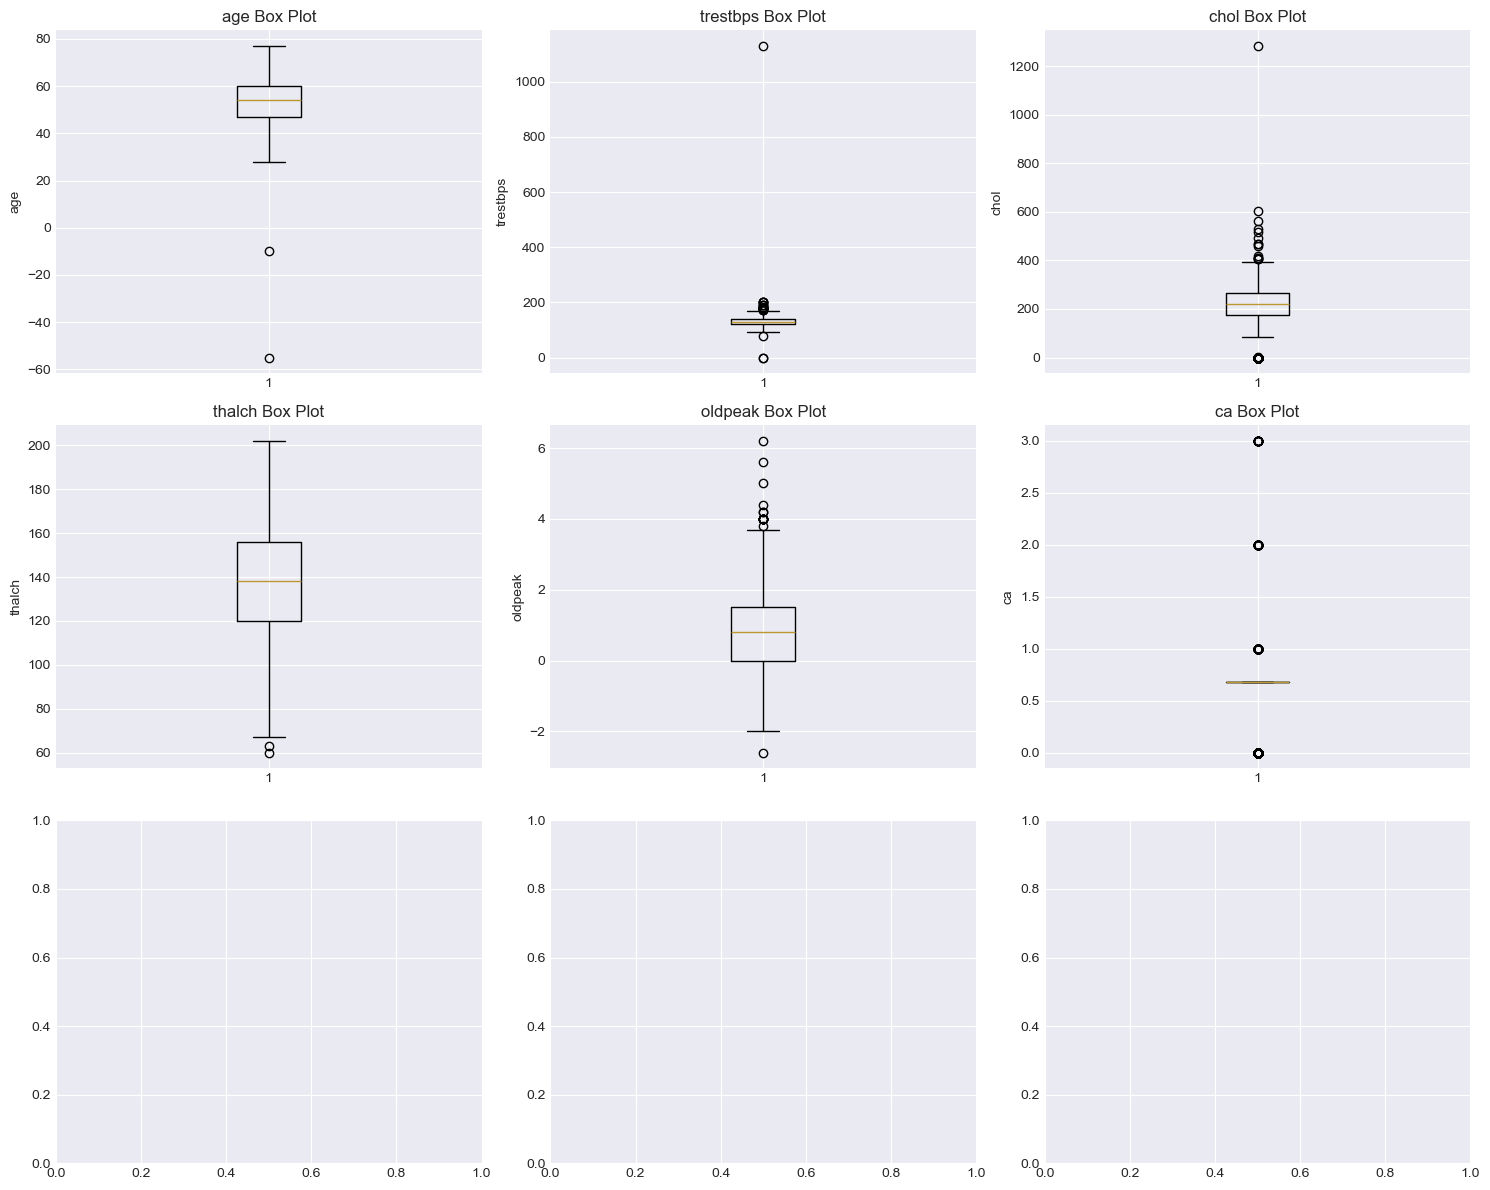

In [12]:
# Box plots to identify outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < 9:
        axes[idx].boxplot(df_clean[col].dropna())
        axes[idx].set_title(f'{col} Box Plot')
        axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

In [13]:
# Use Local Outlier Factor (LOF) for outlier detection
# Prepare data for LOF (only numerical features)
lof_features = df_clean[numerical_cols].copy()

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outlier_labels = lof.fit_predict(lof_features)

# Count outliers
n_outliers = (outlier_labels == -1).sum()
print(f"Number of outliers detected by LOF: {n_outliers}")
print(f"Percentage of outliers: {(n_outliers / len(df_clean)) * 100:.2f}%")

# Add outlier labels to dataframe
df_clean['outlier'] = outlier_labels

# Option to remove outliers (commented out - depends on domain knowledge)
# df_clean_no_outliers = df_clean[df_clean['outlier'] == 1].drop('outlier', axis=1)
# print(f"Rows after removing outliers: {len(df_clean_no_outliers)}")

# For this analysis, we'll keep outliers but flag them
print("\nOutliers flagged but retained for further analysis.")

Number of outliers detected by LOF: 92
Percentage of outliers: 10.02%

Outliers flagged but retained for further analysis.


## 4. Data Transformation

### 4.1 Data Encoding

In [14]:
# Prepare data for encoding
df_encoded = df_clean.copy()

# Display categorical columns
print("Categorical columns to encode:")
for col in categorical_cols:
    print(f"{col}: {df_encoded[col].unique()}")

Categorical columns to encode:
sex: ['Male' 'Female']
dataset: ['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']
cp: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
fbs: [True False]
restecg: ['lv hypertrophy' 'normal' 'st-t abnormality']
exang: [False True]
slope: ['downsloping' 'flat' 'upsloping']
thal: ['fixed defect' 'normal' 'reversable defect']


In [15]:
# Ordinal Encoding for features with natural order
ordinal_features = ['slope']  # slope has natural order: upsloping < flat < downsloping

# Define the order for ordinal features
slope_order = [['upsloping', 'flat', 'downsloping']]

if 'slope' in df_encoded.columns:
    ordinal_encoder = OrdinalEncoder(categories=slope_order)
    df_encoded['slope_encoded'] = ordinal_encoder.fit_transform(df_encoded[['slope']])
    print("\nOrdinal Encoding applied to 'slope':")
    print(df_encoded[['slope', 'slope_encoded']].head())


Ordinal Encoding applied to 'slope':
         slope  slope_encoded
0  downsloping            2.0
1         flat            1.0
3         flat            1.0
4  downsloping            2.0
5    upsloping            0.0


In [16]:
# One-Hot Encoding for nominal categorical features
nominal_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'thal']
nominal_features = [f for f in nominal_features if f in df_encoded.columns]

print(f"\nApplying One-Hot Encoding to: {nominal_features}")

# Apply One-Hot Encoding
df_encoded_onehot = pd.get_dummies(df_encoded, columns=nominal_features, drop_first=True, prefix=nominal_features)

print(f"\nShape before encoding: {df_encoded.shape}")
print(f"Shape after encoding: {df_encoded_onehot.shape}")
print(f"\nNew columns after one-hot encoding:")
new_cols = [col for col in df_encoded_onehot.columns if col not in df_encoded.columns]
print(new_cols)


Applying One-Hot Encoding to: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'thal']

Shape before encoding: (918, 18)
Shape after encoding: (918, 22)

New columns after one-hot encoding:
['sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'thal_normal', 'thal_reversable defect']


### 4.2 Data Normalization and Standardization

In [17]:
# Prepare numerical features for scaling
features_to_scale = [col for col in numerical_cols if col in df_encoded_onehot.columns]

print(f"Features to scale: {features_to_scale}")

# Check distributions before scaling
print("\nStatistical summary before scaling:")
print(df_encoded_onehot[features_to_scale].describe())

Features to scale: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

Statistical summary before scaling:
             age     trestbps         chol      thalch     oldpeak          ca
count  918.00000   918.000000   918.000000  918.000000  918.000000  918.000000
mean    53.30719   133.186623   199.973440  137.540452    0.880751    0.681348
std     10.29422    37.983863   114.939235   25.146685    1.054122    0.542269
min    -55.00000     0.000000     0.000000   60.000000   -2.600000    0.000000
25%     47.00000   120.000000   177.000000  120.000000    0.000000    0.683871
50%     54.00000   130.000000   221.000000  138.000000    0.800000    0.683871
75%     60.00000   140.000000   267.000000  155.750000    1.500000    0.683871
max     77.00000  1130.000000  1283.000000  202.000000    6.200000    3.000000


In [18]:
# Min-Max Normalization (scales to [0, 1])
df_normalized = df_encoded_onehot.copy()
scaler_minmax = MinMaxScaler()
df_normalized[features_to_scale] = scaler_minmax.fit_transform(df_normalized[features_to_scale])

print("\nAfter Min-Max Normalization:")
print(df_normalized[features_to_scale].describe())


After Min-Max Normalization:
              age    trestbps        chol      thalch     oldpeak          ca
count  918.000000  918.000000  918.000000  918.000000  918.000000  918.000000
mean     0.820509    0.117864    0.155864    0.546060    0.395540    0.227116
std      0.077987    0.033614    0.089586    0.177089    0.119787    0.180756
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000
25%      0.772727    0.106195    0.137958    0.422535    0.295455    0.227957
50%      0.825758    0.115044    0.172253    0.549296    0.386364    0.227957
75%      0.871212    0.123894    0.208106    0.674296    0.465909    0.227957
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000


In [19]:
# Standardization (mean=0, std=1)
df_standardized = df_encoded_onehot.copy()
scaler_standard = StandardScaler()
df_standardized[features_to_scale] = scaler_standard.fit_transform(df_standardized[features_to_scale])

print("\nAfter Standardization:")
print(df_standardized[features_to_scale].describe())


After Standardization:
                age      trestbps          chol        thalch       oldpeak            ca
count  9.180000e+02  9.180000e+02  9.180000e+02  9.180000e+02  9.180000e+02  9.180000e+02
mean  -2.322035e-16 -3.792657e-16  1.238419e-16 -3.096047e-17 -6.966105e-17 -8.804383e-17
std    1.000545e+00  1.000545e+00  1.000545e+00  1.000545e+00  1.000545e+00  1.000545e+00
min   -1.052690e+01 -3.508312e+00 -1.740767e+00 -3.085207e+00 -3.303838e+00 -1.257161e+00
25%   -6.130263e-01 -3.473531e-01 -1.999836e-01 -6.979056e-01 -8.359861e-01  4.655239e-03
50%    6.733761e-02 -8.393987e-02  1.830360e-01  1.828465e-02 -7.664702e-02  4.655239e-03
75%    6.505067e-01  1.794733e-01  5.834657e-01  7.245279e-01  5.877747e-01  4.655239e-03
max    2.302819e+00  2.625738e+01  9.427737e+00  2.564739e+00  5.048892e+00  4.278164e+00


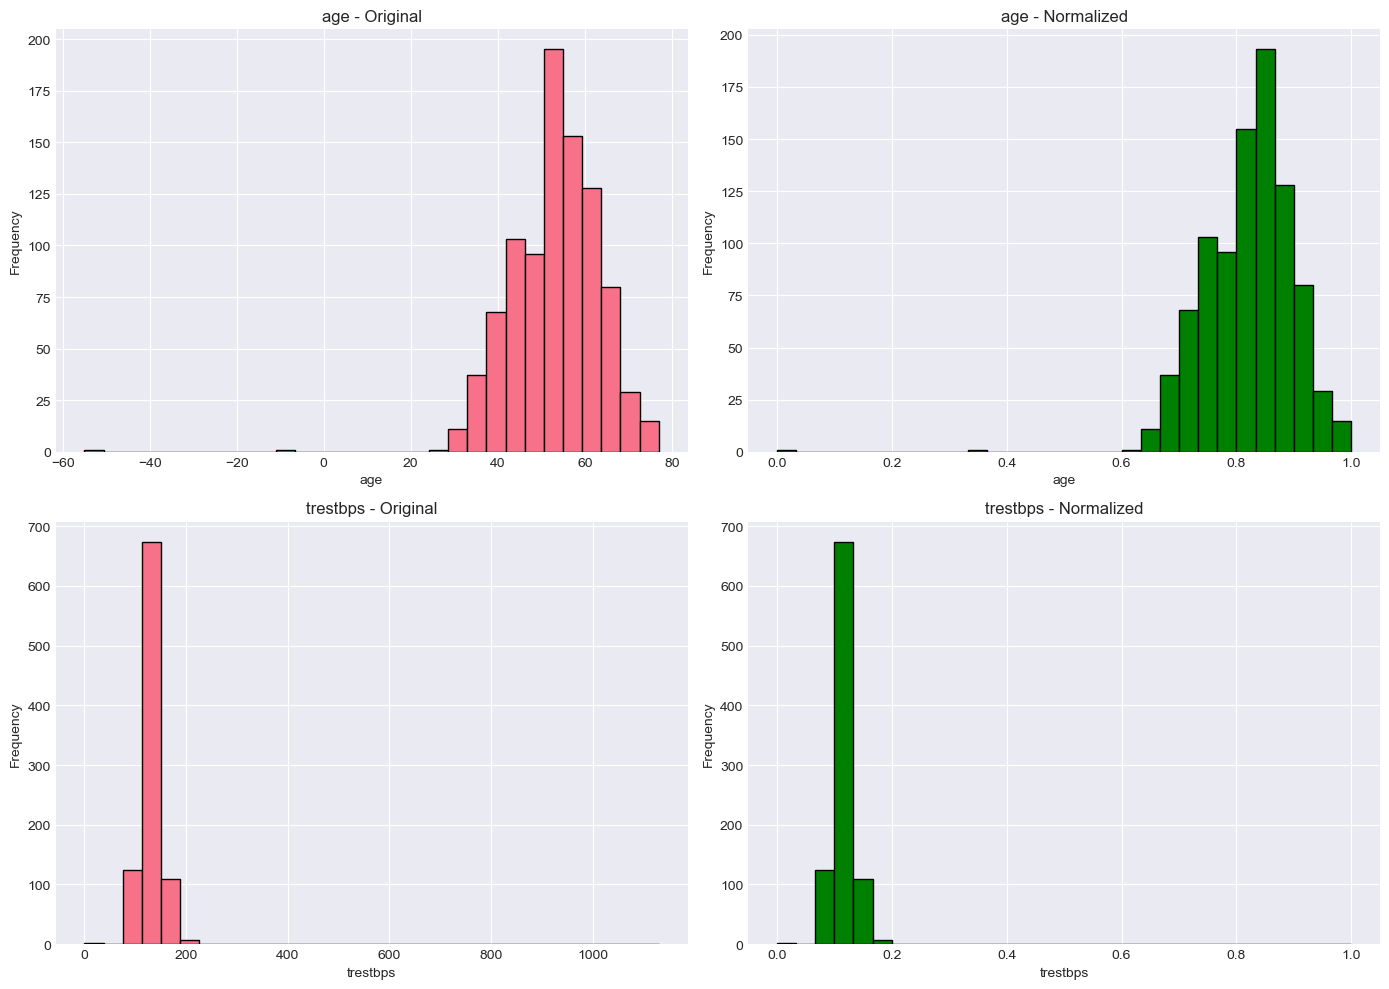

In [20]:
# Visualize before and after scaling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select a few features for visualization
viz_features = features_to_scale[:2]

for idx, feature in enumerate(viz_features):
    # Original
    axes[idx, 0].hist(df_encoded_onehot[feature], bins=30, edgecolor='black')
    axes[idx, 0].set_title(f'{feature} - Original')
    axes[idx, 0].set_xlabel(feature)
    axes[idx, 0].set_ylabel('Frequency')
    
    # Normalized
    axes[idx, 1].hist(df_normalized[feature], bins=30, edgecolor='black', color='green')
    axes[idx, 1].set_title(f'{feature} - Normalized')
    axes[idx, 1].set_xlabel(feature)
    axes[idx, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5.Saving Processed Dataset

In [21]:
# Save processed datasets
df_clean.to_csv('heart_disease_cleaned.csv', index=False)
df_normalized.to_csv('heart_disease_normalized.csv', index=False)
df_standardized.to_csv('heart_disease_standardized.csv', index=False)

print("Processed datasets saved:")
print("- heart_disease_cleaned.csv")
print("- heart_disease_normalized.csv")
print("- heart_disease_standardized.csv")

Processed datasets saved:
- heart_disease_cleaned.csv
- heart_disease_normalized.csv
- heart_disease_standardized.csv
